In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("student_data.csv")

In [3]:
pd.set_option("display.max_columns", 100)
df.sample(1)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
69,GP,F,15,R,LE3,T,3,1,other,other,reputation,father,2,4,0,no,yes,no,no,no,yes,yes,no,4,4,2,2,3,3,12,16,16,16


In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10


In [6]:
df.drop(['school', 'Pstatus', 'reason', 'guardian', 'failures', 'schoolsup', 'famsup', 'nursery', 'higher', 'romantic', 'famrel', 'Dalc', 'Walc', 'G2', 'internet', 'activities', 'paid', 'traveltime', 'famsize', 'address'], axis=1, inplace=True)

In [7]:
print(df.isnull().sum())

sex          0
age          0
Medu         0
Fedu         0
Mjob         0
Fjob         0
studytime    0
freetime     0
goout        0
health       0
absences     0
G1           0
G3           0
dtype: int64


In [8]:
df['result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [9]:
df.drop('G3', axis=1, inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [11]:
X = df.drop('result', axis=1)

y = df['result']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.8607594936708861


In [15]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        27
           1       0.90      0.88      0.89        52

    accuracy                           0.86        79
   macro avg       0.84      0.85      0.85        79
weighted avg       0.86      0.86      0.86        79



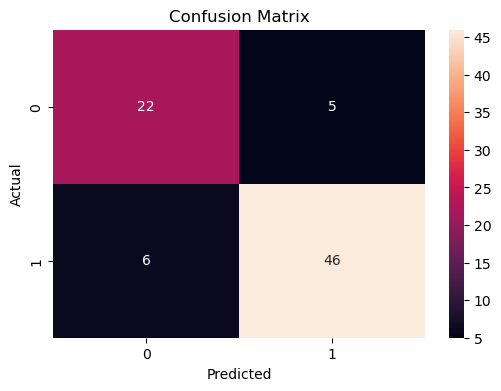

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:")

print(accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy:
0.7848101265822784


In [18]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.71      0.63      0.67        27
           1       0.82      0.87      0.84        52

    accuracy                           0.78        79
   macro avg       0.76      0.75      0.75        79
weighted avg       0.78      0.78      0.78        79



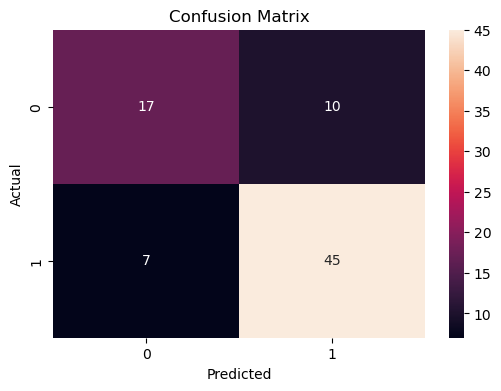

In [19]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")

print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.8354430379746836


In [21]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.75      0.78      0.76        27
           1       0.88      0.87      0.87        52

    accuracy                           0.84        79
   macro avg       0.82      0.82      0.82        79
weighted avg       0.84      0.84      0.84        79



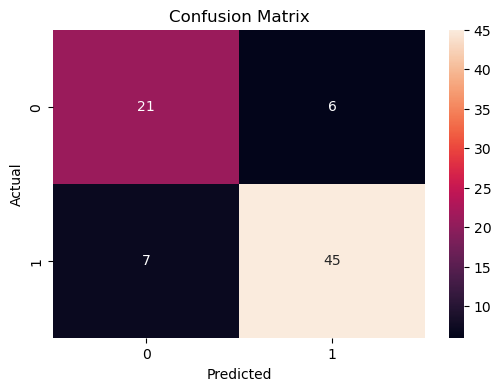

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
importance = rf.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

imp_df = imp_df.sort_values(by='Importance', ascending=False)

print(imp_df.head(10))

     Feature  Importance
11        G1    0.437349
10  absences    0.103902
1        age    0.078130
8      goout    0.059319
9     health    0.049914
4       Mjob    0.047576
2       Medu    0.043804
7   freetime    0.043587
3       Fedu    0.042959
5       Fjob    0.040047


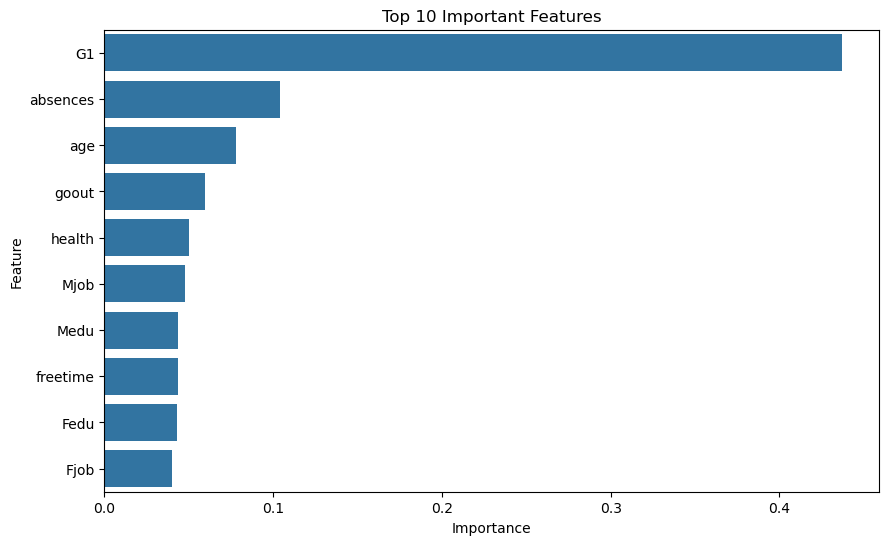

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=imp_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [25]:
df.columns

Index(['sex', 'age', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'studytime', 'freetime',
       'goout', 'health', 'absences', 'G1', 'result'],
      dtype='object')

In [26]:
df

,sex,age,Medu,Fedu,Mjob,Fjob,studytime,freetime,goout,health,absences,G1,result
0,0,18,4,4,0,4,2,3,4,3,6,5,0
1,0,17,1,1,0,2,2,3,3,3,4,5,0
2,0,15,1,1,0,2,2,3,2,3,10,7,1
3,0,15,4,2,1,3,3,2,2,5,2,15,1
4,0,16,3,3,2,2,2,3,2,5,4,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,20,2,2,3,3,2,5,4,4,11,9,0
391,1,17,3,1,3,3,1,4,5,2,3,14,1
392,1,21,1,1,2,2,1,5,3,3,3,10,0
393,1,18,3,2,3,2,1,4,1,5,0,11,1


In [27]:
import pickle

In [ ]:
pickle.dump(rf, open('model.pkl', 'wb'))